In [ ]:
# s4U-pulsed APEX-seq structure information 


In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from statannot import add_stat_annotation 
from Bio import SeqIO             
from sklearn import metrics    

In [ ]:
## 1. Extend Figure 5d-5f --- --- 
### 1_1. Extend Fig5d --- --- 
### 1_2. Extend Fig5e --- --- 
### 1_3. Extend Fig5f --- --- 

In [ ]:
### 1_1. Extend Fig5d --- --- 

(16569, 29)
(15010, 29)
(1743, 29)
G_Label v.s. G_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.388e-03 U_stat=2.653e+05
U_Label v.s. U_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=2.478e-169 U_stat=1.524e+06
A_Label v.s. A_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.117e-55 U_stat=1.640e+06
C_Label v.s. C_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=5.610e-32 U_stat=1.704e+06
                mod_rate
Sequence group          
A        Ctrl   0.000000
         Label  0.000386
C        Ctrl   0.000000
         Label  0.000452
G        Ctrl   0.000351
         Label  0.000466
N        Label  0.020360
U        Ctrl   0.000728
         Label  0.003996


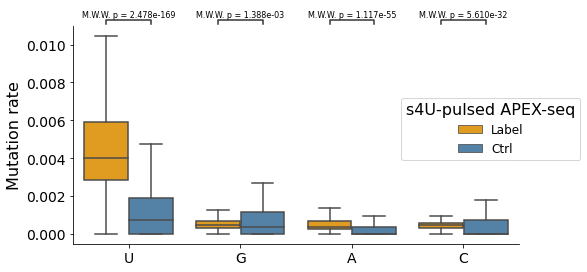

In [2]:
dir = "./Data/"
s4U_apex = pd.read_csv(dir+'s4U_apex_mito_1_NC_012920.1_Homo_sapiens_mitochondrion_complete_genome_profile.txt',sep='\t')
print(s4U_apex.shape)

s4U_apex_label = s4U_apex[s4U_apex['Modified_effective_depth'] >=2500]
print(s4U_apex_label.shape)
s4U_apex_label = s4U_apex_label[['Nucleotide','Sequence','Modified_rate']]
s4U_apex_label.columns=['Nucleotide','Sequence','mod_rate']
s4U_apex_label['group'] = 'Label'

s4U_apex_ctrl = s4U_apex[s4U_apex['Untreated_effective_depth'] >=2500]
print(s4U_apex_ctrl.shape)
s4U_apex_ctrl = s4U_apex_ctrl[['Nucleotide','Sequence','Untreated_rate']]
s4U_apex_ctrl.columns=['Nucleotide','Sequence','mod_rate']
s4U_apex_ctrl['group'] = 'Ctrl'

s4U_apex_flt = pd.concat([s4U_apex_label,s4U_apex_ctrl])
dplot = s4U_apex_flt

dplot.to_csv('./Data/'+'source_data_Efig5d.csv',sep=',')

### plots ---

plt.figure(figsize=(8,4))

order = ['U','G', 'A',  'C']
my_pal = {'Label': "orange", 'Ctrl': "steelblue"}
ax = sns.boxplot(data=dplot, x='Sequence',y='mod_rate', hue='group',showfliers = False,order = order, palette = my_pal)     #palette = my_pal

plt.title(' ',fontsize = 18)
plt.xlabel('',fontsize = 16) 
plt.ylabel('Mutation rate',fontsize = 16)
plt.xticks(fontsize = 14) 
plt.yticks(fontsize = 14) 
legend=plt.legend(loc='best', title='s4U-pulsed APEX-seq',bbox_to_anchor=(1.15, 0.7),prop={'size': 12})
legend.get_title().set_fontsize('16') 
ax.spines[['right', 'top']].set_visible(False) 

add_stat_annotation(ax, data=dplot, x='Sequence',y='mod_rate', hue='group', order=order, 
                    box_pairs = [(("U", 'Label'), ("U", 'Ctrl')),
                                 (("A", 'Label'), ("A", 'Ctrl')),
                                 (("C", 'Label'), ("C", 'Ctrl')),
                                 (("G", 'Label'), ("G", 'Ctrl'))
                                ],
                    test="Mann-Whitney", text_format='full', loc='outside', line_offset_to_box=0.01, verbose=1,fontsize=8)  #line_offset_to_box=-0.001,

dir_out = "./Data/"
plt.savefig(dir_out+'Extend_Fig5d_s4U-pulsed_APEX_RNA_mutation_rate_label_vs_Ctrl.pdf',bbox_inches='tight', dpi=300) 

print(dplot.groupby(['Sequence','group']).median()[['mod_rate']])  

In [3]:
print(dplot.groupby(['Sequence','group']).mean()[['mod_rate']]) 

                mod_rate
Sequence group          
A        Ctrl   0.000415
         Label  0.003369
C        Ctrl   0.002321
         Label  0.001877
G        Ctrl   0.002353
         Label  0.003533
N        Label  0.020360
U        Ctrl   0.001278
         Label  0.005264


In [4]:
print(dplot.groupby(["Sequence", "group"]).count())  

                Nucleotide  mod_rate
Sequence group                      
A        Ctrl          500       500
         Label        4587      4587
C        Ctrl          545       545
         Label        4773      4773
G        Ctrl          236       236
         Label        1968      1968
N        Label           1         1
U        Ctrl          462       462
         Label        3681      3681


In [ ]:
### 1_2. Extend Fig4e --- --- 

In [5]:
def convert_dot(input_file,rna): 
    sequences=[i for i in SeqIO.parse(open(input_file),'fasta')] 
    
    seq_0 = str(sequences[0].seq)
    length = len(seq_0)
    base = seq_0[0:int(length/2)]
    dot = seq_0[int(length/2):int(length)]
    
    base = list(map(lambda i:i, base))
    dot = list(map(lambda i:i, dot))
    strand = list(map(lambda i: 1 if i == "." else 0, dot))
    Nucleotide = range(1,len(strand)+1)
    
    bench = pd.DataFrame(list(zip(base,dot,strand,Nucleotide)),
              columns=['base','dot','strand','Position2'])
    bench.to_csv('./Data/'+rna+'_base_dot_strand.csv',sep='\t')
    
    return bench 

In [6]:
#### A. input 
dir = "./Data/"
s4U_apex = pd.read_csv(dir+'s4U_apex_mito_1_NC_012920.1_Homo_sapiens_mitochondrion_complete_genome_profile.txt',sep='\t')
cox1= s4U_apex[(s4U_apex['Nucleotide']>=5900) & (s4U_apex['Nucleotide']<=7517)]
cox1=cox1[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
print(cox1.shape)
cox1['Nucleotide']=cox1['Nucleotide']-5899
cox1['Position2'] =cox1['Nucleotide']

#### B. bench 
dir_bench = './Data/bench/'
bench = convert_dot(dir_bench+'bench_positive_COX1_1_1618_162.dot','COX1')

#### C. combine 
df = pd.merge(cox1,bench, how='left',on=['Position2','Position2'])

#### D. SS and DS regions
dplot=df
tmp1 = dplot[dplot['strand'] == 1]
tmp1['region'] = 'SS'
tmp2 = dplot[dplot['strand'] == 0]
tmp2['region'] = 'DS'
dplot = pd.concat([tmp1,tmp2], ignore_index=True)
dplott = dplot[(dplot['base'] =='T') | (dplot['base'] =='U')]

dplott.to_csv('./Data/'+'source_data_Efig5e.csv',sep=',')

(1618, 8)


/tmp/ipykernel_6863/2336903011.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp1['region'] = 'SS'
/tmp/ipykernel_6863/2336903011.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp2['region'] = 'DS'


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


SS v.s. DS: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=9.544e-04 U_stat=1.773e+04


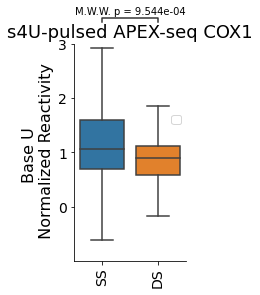

In [7]:
#### plot 

plt.figure(figsize=(2,4))

order = ['SS', 'DS']
ax = sns.boxplot(data=dplott, x='region',y='Norm_profile', showfliers = False,order = order, dodge = False) 

plt.title('s4U-pulsed APEX-seq COX1',fontsize = 18)
plt.xlabel('',fontsize = 16) 
plt.ylabel('Base U \n Normalized Reactivity',fontsize = 16)
plt.ylim(-1,3)
plt.xticks(fontsize = 14,rotation=90) 
plt.yticks([0,1,2,3],fontsize = 14) 
plt.legend(loc='best', bbox_to_anchor=(1.01, 0.7),prop={'size': 12})
ax.spines[['right', 'top']].set_visible(False) 

add_stat_annotation(ax, data = dplott, x = dplott['region'], y = dplott['Norm_profile'], order=order, 
                    box_pairs = [('SS','DS')],
                    test="Mann-Whitney", text_format='full', loc='outside', line_offset_to_box=0.1, verbose=3)  #line_offset_to_box=-0.001,

dir_out = "./Data/"
plt.savefig(dir_out+'Extend_Fig5e_s4U-pulsed_APEX_COX1_baseU_react_SS_vs_DS.pdf',bbox_inches='tight', dpi=300) 

In [8]:
print(dplot.groupby(["region"]).count())  

        Nucleotide  Sequence  Modified_effective_depth  \
region                                                   
DS             436       436                       436   
SS            1182      1182                      1182   

        Untreated_effective_depth  Modified_rate  Untreated_rate  \
region                                                             
DS                            436            436             436   
SS                           1182           1182            1182   

        Reactivity_profile  Norm_profile  Position2  base   dot  strand  
region                                                                   
DS                     436           417        436   436   436     436  
SS                    1182          1099       1182  1182  1182    1182  


In [ ]:
### 1_3. Extend Fig4f --- --- ---

In [9]:
def convert_dot(input_file,rna): 
    sequences=[i for i in SeqIO.parse(open(input_file),'fasta')] 
    
    seq_0 = str(sequences[0].seq)
    length = len(seq_0)
    base = seq_0[0:int(length/2)]
    dot = seq_0[int(length/2):int(length)]
    
    base = list(map(lambda i:i, base))
    dot = list(map(lambda i:i, dot))
    strand = list(map(lambda i: 1 if i == "." else 0, dot))
    Nucleotide = range(1,len(strand)+1)
    
    bench = pd.DataFrame(list(zip(base,dot,strand,Nucleotide)),
              columns=['base','dot','strand','Position2'])
    bench.to_csv('./Data/'+rna+'_base_dot_strand.csv',sep='\t')
    
    return bench 

(1618, 8)
0.6061356707317074


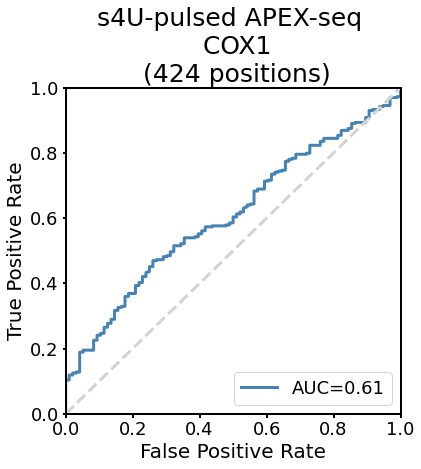

In [10]:
#### A. input 

dir = "./Data/"
s4U_apex = pd.read_csv(dir+'s4U_apex_mito_1_NC_012920.1_Homo_sapiens_mitochondrion_complete_genome_profile.txt',sep='\t')
cox1= s4U_apex[(s4U_apex['Nucleotide']>=5900) & (s4U_apex['Nucleotide']<=7517)]
cox1=cox1[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
print(cox1.shape)
cox1['Nucleotide']=cox1['Nucleotide']-5899
cox1['Position2'] =cox1['Nucleotide']

#### B. bench 

dir_bench = './Data/bench/'
bench = convert_dot(dir_bench+'bench_positive_COX1_1_1618_162.dot','COX1')

#### C. combine 
df = pd.merge(cox1,bench, how='left',on=['Position2','Position2'])
flt=df[(df['base']=='T') | (df['base']=='U')]

flt.to_csv('./Data/'+'source_data_Efig5f.csv',sep=',')

## plot --------------------------

fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(flt.strand, flt.Reactivity_profile, pos_label=1)
roc_auc_1 = metrics.auc(fpr_1, tpr_1)
print(roc_auc_1)

fig, (ax) = plt.subplots(1, 1, figsize = (6, 6))
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
    ax.tick_params(width = 2)
    
plt.title('s4U-pulsed APEX-seq \n COX1'+'\n ('+str(flt.shape[0])+' positions)', fontsize = 25)
plt.plot(fpr_1, tpr_1, color = 'steelblue', linewidth = 3.0, label = 'AUC=%0.2f' % roc_auc_1,)

plt.legend(loc = 'lower right', fontsize = 18)
plt.plot([0, 1], [0, 1], color = 'lightgrey', linewidth = 3.0, linestyle = 'dashed')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize = 20)
plt.xlabel('False Positive Rate', fontsize = 20)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)

dir_out = "./Data/"
plt.savefig(dir_out+'Extend_Fig5f_s4U-pulsed_APEX_COX1_baseU_AUROC.pdf',bbox_inches='tight', dpi=300) 